In [74]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

In [32]:
df = pd.read_csv('medical_insurance.csv')

In [23]:
# EDA

In [8]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [9]:
df.tail()

,age,sex,bmi,children,smoker,region,charges
2767,47,female,45.320,1,no,southeast,8569.86180
2768,21,female,34.600,0,no,southwest,2020.17700
2769,19,male,26.030,1,yes,northwest,16450.89470
2770,23,male,18.715,0,no,northwest,21595.38229
2771,54,male,31.600,0,no,southwest,9850.43200


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2772 non-null   int64  
 1   sex       2772 non-null   object 
 2   bmi       2772 non-null   float64
 3   children  2772 non-null   int64  
 4   smoker    2772 non-null   object 
 5   region    2772 non-null   object 
 6   charges   2772 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 151.7+ KB


In [11]:
df.describe()

,age,bmi,children,charges
count,2772.000000,2772.000000,2772.000000,2772.000000
mean,39.109668,30.701349,1.101732,13261.369959
std,14.081459,6.129449,1.214806,12151.768945
min,18.000000,15.960000,0.000000,1121.873900
25%,26.000000,26.220000,0.000000,4687.797000
50%,39.000000,30.447500,1.000000,9333.014350
75%,51.000000,34.770000,2.000000,16577.779500
max,64.000000,53.130000,5.000000,63770.428010


In [12]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [13]:
df.shape

(2772, 7)

In [14]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [16]:
df.duplicated().sum()

1435

In [17]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
2767     True
2768     True
2769     True
2770     True
2771     True
Length: 2772, dtype: bool

In [19]:
df.duplicated(subset=['age','children']).sum()

2553

In [20]:
## cant drop the rows with duplicated values already we have limited number of rows

In [25]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [ ]:
X=df.iloc[:,:-1]
X_encoded = pd.get_dummies(X, drop_first=True) # Label encoding
y=df.iloc[:,-1]
X_train,X_test,y_train,y_test=train_test_split(X_encoded,y,test_size=0.33,random_state=42)

0.749770462049898


In [62]:
from sklearn.preprocessing import StandardScaler # Performing standardization

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [64]:
model=LinearRegression()
model.fit(X_train_scaled,y_train)
y_pred = model.predict(X_test_scaled)

In [67]:
print("R2 score : ", r2_score(y_test,y_pred))

R2 score :  0.7458659546208043


In [68]:
from sklearn.linear_model import Lasso # This is used to prevent overfitting and also used for feature selection
from sklearn.model_selection import GridSearchCV # Used for hyperparameter tuning
from sklearn.metrics import r2_score

lasso = Lasso(max_iter=10000)

params = {
    'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10]
}

grid = GridSearchCV(lasso, params, scoring='r2', cv=5)
grid.fit(X_train, y_train)

best_lasso = grid.best_estimator_

y_pred_lasso = best_lasso.predict(X_test)

print("Best alpha:", grid.best_params_)
print("Lasso R2:", r2_score(y_test, y_pred_lasso))


Best alpha: {'alpha': 10}
Lasso R2: 0.7456959265154848


In [69]:
import numpy as np

print("Number of features:", X_train.shape[1])
print("Non-zero coefficients:", np.sum(best_lasso.coef_ != 0))


Number of features: 8
Non-zero coefficients: 8


In [61]:
## Lasso was not helpful in doing feature selection and also the results were slightly worse than using linear regression

In [72]:
## Checking with cross val score
scores = cross_val_score(model, X_encoded, y, cv=5, scoring='r2')
print(scores.mean())

0.749770462049898


In [80]:
# Retrain Linear Regression on full dataset
final_model = LinearRegression()
final_model.fit(X_encoded, y)

LinearRegression()

In [84]:
y_pred_full = final_model.predict(X_encoded)
print("R2 score : ", r2_score(y,y_pred_full))

R2 score :  0.7509331524312296


In [ ]:
## Results with cross val score are better than train test split so we will go with corss val score

In [86]:
# This is a regression problem with noisy data so hence R^2 values is ~ 75 percent

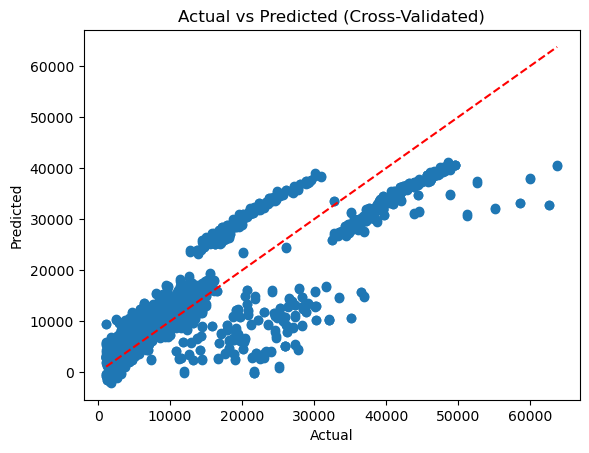

In [ ]:
from sklearn.model_selection import cross_val_predict

y_pred_cv = cross_val_predict(model, X_encoded, y, cv=5)

plt.scatter(y, y_pred_cv)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # reference line
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted (Cross-Validated)")
plt.show()
